In [6]:
import matplotlib.pyplot as plt
import numpy as np
import dask
import xarray as xr
import rioxarray as rxr
import cartopy.crs as ccrs

In [7]:
ESM5_data = xr.open_dataset(
    "/Users/filipnovak/Documents/ML_geosciences/CanESM_1850-2100_rsutcs.nc",
    engine="netcdf4",
    chunks={"time": 12},
    decode_times=True,
    use_cftime=True
)


/var/folders/g2/cdqgt5_n6_qgq1m_sjk9x3r00000gn/T/ipykernel_73580/399627588.py:1: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ESM5_data = xr.open_dataset(
/var/folders/g2/cdqgt5_n6_qgq1m_sjk9x3r00000gn/T/ipykernel_73580/399627588.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  ESM5_data = xr.open_dataset(


<xarray.Dataset> Size: 2GB
Dimensions:  (member: 25, time: 3012, lat: 64, lon: 128)
Coordinates:
  * member   (member) int64 200B 0 1 2 3 4 5 6 7 8 ... 17 18 19 20 21 22 23 24
  * time     (time) object 24kB 1850-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
Data variables:
    rsutcs   (member, time, lat, lon) float32 2GB dask.array<chunksize=(5, 12, 16, 32), meta=np.ndarray>

Dimensions: FrozenMappingWarningOnValuesAccess({'member': 25, 'time': 3012, 'lat': 64, 'lon': 128})
Coordinates: ['time', 'lat', 'lon', 'member']
Data variables: ['rsutcs']


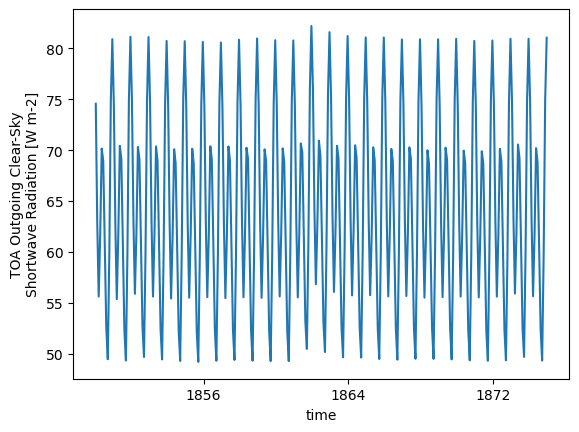

In [8]:
da = ESM5_data["rsutcs"]

# Dataset overview
print(ESM5_data)
print("\nDimensions:", ESM5_data.dims)
print("Coordinates:", list(ESM5_data.coords))
print("Data variables:", list(ESM5_data.data_vars))


test_series = da.mean(["lat", "lon", "member"]).isel(time=slice(0,300)).compute()
test_series.plot()

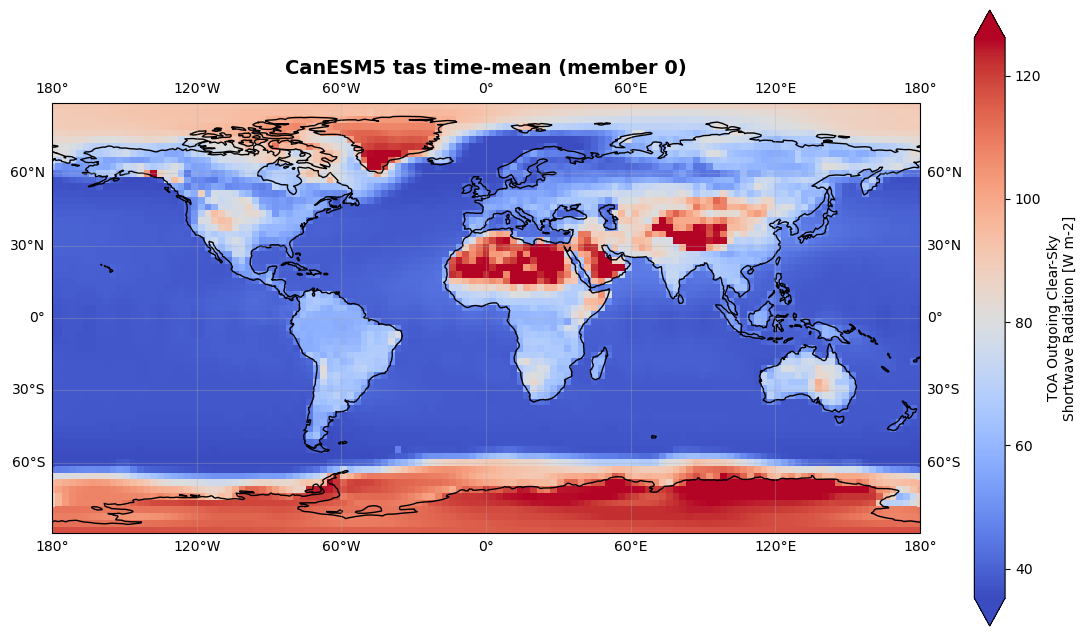

In [9]:
# Map of rsutcs (time-mean, member 0)
map_da = ESM5_data["rsutcs"]
if "time" in map_da.dims:
    map_da = map_da.mean("time")
if "member" in map_da.dims:
    map_da = map_da.isel(member=0)

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(linewidth=1)
ax.gridlines(draw_labels=True, alpha=0.3)

map_da.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="coolwarm", robust=True, x="lon", y="lat")
plt.title("CanESM5 tas time-mean (member 0)", fontsize=14, fontweight="bold")
plt.show()